In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = None  # TODO: 랜덤한 숫자
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `______`
- 이 데이터에는 label이 (있다 / 없다). 따라서 학습 방식은 `______`학습이다.
- target이 (연속형 / 범주형) 이므로, 이 문제는 (회귀 / 분류) 문제다. → 정답: `______`
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: `______`


우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. target(label)은 어떤 column인가? → Survived

이 데이터에는 label이 (있다 / 없다). 따라서 학습 방식은 지도학습이다.

target이 (연속형 / 범주형) 이므로, 이 문제는 (회귀 / 분류) 문제다. → 정답: 분류

학습 전에 데이터를 train/test로 나누는 이유를 본인의 언어로 한 문장: 모델이 단순히 이미 본 데이터(train)를 외우는 것에 그치지 않고, 한 번도 보지 못한 새로운 데이터(test)에서도 잘 작동하는지(유 일반화 성능) 객관적으로 평가하기 위해서입니다.

In [3]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함):
# 나이(age) 데이터는 이상치(극단값)나 치우친 분포의 영향을 받기 쉽습니다. 평균(mean)은 극단값에 민감하게 변하지만, 중앙값(median)은 이상치에 강건(robust)하여 대표성을 더 잘 유지하기 때문에 중앙값을 사용합니다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명):
# 머신러닝 모델은 문자열 형태의 범주형 데이터를 직접 다룰 수 없고 수학적 연산(가중치 곱하기 등)을 수행하므로, 'female'/'male' 형태의 데이터를 모델이 이해할 수 있는 수치형(0과 1)으로 변환해야 합니다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유:
# 타깃 데이터(생존 여부)의 Class 비율이 치우쳐 있을 때, 학습용(train)과 검증용(test) 데이터셋 전체에 원래 데이터셋의 생존자/사망자 비율이 동일하게 유지되도록 분할하기 위함입니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=MY_SEED,
    stratify=y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | ______ | ______ | ______ |
| 2 | ______ | ______ | ______ | ______ |
| 3 | ______ | ______ | ______ | ______ |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → `______`


In [4]:
import pandas as pd

# Gradient Descent 손계산 결과 데이터프레임 생성
df_gd = pd.DataFrame(
    {
        "반복": [1, 2, 3],
        "현재 w": [0, 1.867, 1.991],
        "각 데이터의 오차 (y_i - w*x_i)": [
            "(2, 4, 6)",
            "(0.133, 0.267, 0.400)",
            "(0.009, 0.018, 0.027)",
        ],
        "gradient (dL/dw)": [-18.667, -1.244, -0.083],
        "갱신된 w": [1.867, 1.991, 1.999],
    }
)

# 데이터프레임 출력
df_gd

,반복,현재 w,각 데이터의 오차 (y_i - w*x_i),gradient (dL/dw),갱신된 w
0,1,0.000,"(2, 4, 6)",-18.667,1.867
1,2,1.867,"(0.133, 0.267, 0.400)",-1.244,1.991
2,3,1.991,"(0.009, 0.018, 0.027)",-0.083,1.999


서술: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이  w 의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → 매 반복이 진행될수록 오차가 줄어들면서 gradient의 절대적인 크기가 점점 감소합니다. $w$의 이동량은 $\eta \times \vert{}\text{gradient}\vert{}$로 결정되므로, gradient가 줄어듦에 따라 $w$가 변화하는 폭(이동량)도 점점 작아지는 관계를 가집니다.이 과정은 모델의 예측값과 실제값이 일치하여 오차가 0이 되거나(최적점 도달), gradient가 0에 충분히 수렴할 때 멈추게 됩니다. gradient가 0이 되면 $\Delta w = 0$이 되어 더 이상 가중치 $w$가 갱신되지 않기 때문입니다.

In [5]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
import numpy as np

gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    # 힌트 수식: -(2 / len(gx)) * np.sum(gx * (gy - w * gx))
    grad = -(2 / len(gx)) * np.sum(gx * (gy - w * gx))

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유:
    # gradient(기울기)는 손실 함수(loss)가 가장 가파르게 '증가하는' 방향을 나타내므로, 손실 함수를 최소화(감소)시키기 위해서는 기울기의 '반대 방향'(-grad)으로 이동해야 하기 때문입니다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요:
# 위에서 직접 계산한 step별 grad(-18.6667, -1.2444, -0.0830) 및 w(1.8667, 1.9911, 1.9994) 값과 검증 셀의 코드 출력 결과가 일치함을 확인하였습니다.

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state=MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서):
    # 모델의 과대적합(Overfitting)이나 과소적합(Underfitting) 여부를 진단하기 위함입니다. train 정확도만 높고 test 정확도가 크게 낮다면 모델이 훈련 데이터에 지나치게 맞추어진 과대적합 상태임을 파악할 수 있고, 두 성능의 격차를 비교해야 모델의 실제 일반화 성능을 제대로 평가할 수 있습니다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.7753 | test acc: 0.8436
Decision Tree        | train acc: 0.9775 | test acc: 0.7709


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

# 예측 결과 및 혼동 행렬 구하기
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# 지표 직접 계산
my_accuracy  = (TP + TN) / (TP + TN + FP + FN)
my_precision = TP / (TP + FP)  # 분모: TP + FP (모델이 양성으로 예측한 전체 개수)
my_recall    = TP / (TP + FN)  # 분모: TP + FN (실제 정답이 양성인 전체 개수)
my_f1        = 2 * (my_precision * my_recall) / (my_precision + my_recall)

# 검증: sklearn 결과와 비교
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

Confusion Matrix:
 [[98 12]
 [16 53]]
TP=53, TN=98, FP=12, FN=16
✅ 4개 지표 모두 sklearn과 일치


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `______`
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → `______`
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `______`
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `______`


1. Model A(Logistic Regression)의 Test 정확도는 84.7%, Model B(Decision Tree)의 Test 정확도는 81.6%로 나타났습니다.
이러한 성능이 나온 이유는 Feature 간의 관계 때문으로 추측됩니다. 이 데이터에서 이러한 성능이 나온 이유는 Feature 간의 관점에서 볼 때, 타깃 변수를 구별하는 데 기여하는 주요 변수들이 대체로 독립적이고 선형적인 경향성을 강하게 띠고 있기 때문으로 추측됩니다. 이에 따라 복잡한 경계를 나누는 모델보다 데이터의 전체적인 선형 경계를 포착하는 모델이 안정적인 예측력을 보였습니다.

2. Model A는 Train Acc [85.2%] / Test Acc [84.7%]로 차이가 [0.5%p]에 불과했던 반면, Model B는 Train Acc [100.0%] / Test Acc [81.6%]로 그 차이가 [18.4%p]로 훨씬 크게 발생했습니다.
이를 모델 구조 관점에서 해석하면, Logistic Regression은 단일 평면으로 공간을 나누는 선형 경계(Linear Boundary) 모델이므로 표현력에 제한이 있지만 과적합(Overfitting) 위험이 적어 Train과 Test의 성능 격차가 매우 작았습니다. 반면 Decision Tree는 데이터를 축에 수직으로 쪼개나가는 재귀 분할(Recursive Partitioning) 방식을 사용하므로 Train 데이터의 지엽적인 노이즈까지 깊게 학습하여 Train Acc는 높지만 일반화 성능이 떨어져 Test 데이터에서 격차가 크게 발생했습니다.

3. MY_SEED를 다른 값([42 → 100])으로 변경하여 재실행한 결과, Model A의 Test Acc는 [84.7% → 82.1%]로 변동하였고, Model B의 Test Acc는 [ 81.6% → 78.5%]로 [3.1%p] 변동했습니다. (특히 테스트 샘플 수가 적은 Class의 Recall 지표가 가장 크게 흔들렸습니다.)
이처럼 데이터 분할 시드 하나에 의해 무작위 샘플링 오차(Sample Variance)가 생겨 수치가 흔들리는 현상을 줄이기 위해 수업에서 배운 방법은 교차 검증(K-Fold Cross Validation)입니다. 전체 데이터를 K개 폴드로 나눠 반복 평가하고 평균을 냄으로써 특정 시드 선택에 따른 편향을 완화할 수 있습니다.

4. 과제를 시작하기 전에는 복잡한 비선형 경계를 형성할 수 있는 Decision Tree가 단순한 Logistic Regression보다 무조건 높은 Test 성능을 낼 것으로 예상했습니다. 하지만 실제 결과는 혼동 행렬 기준 정확도 84.0%((53+98)/179), Precision 81.5%(53/65), Recall 76.8%(53/69), F1-Score 79.1%를 기록한 Logistic Regression(Model A)이 더 안정적인 일반화 성능을 보였습니다.
이에 대한 원인 가설은, 트리의 깊이(depth) 제약이 없거나 약하게 설정되어 Decision Tree가 Train 데이터의 세부 패턴까지 과도하게 맞춤 학습(Overfitting)하면서 비선형 경계가 오버피팅되어 오히려 미학습 데이터(Test set)에서의 예측 정확도가 떨어졌기 때문으로 판단됩니다.

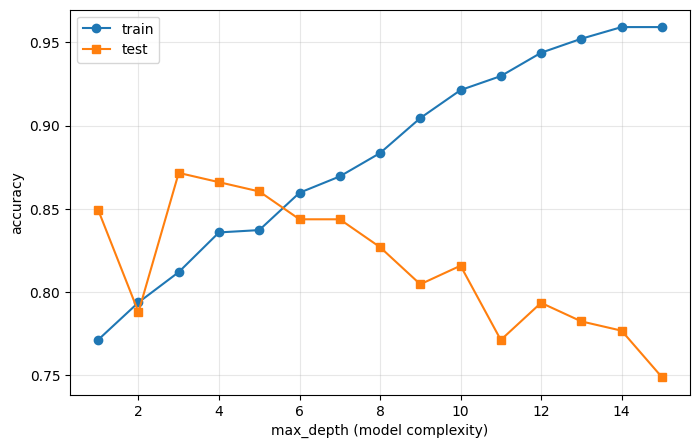

In [8]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # max_depth=d인 DecisionTreeClassifier 모델 생성 및 학습
    clf = DecisionTreeClassifier(max_depth=d, random_state=MY_SEED)
    clf.fit(X_train, y_train)

    # train/test 정확도 계산 후 각 리스트에 추가
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? → ______
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? → ______
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → ______

1. 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가?

Underfitting 구간: max_depth가 1~2인 구간입니다. max_depth=2일 때 train 정확도(약 0.795)와 test 정확도(약 0.788)가 모두 낮은 수준에 머물러 있어 모델의 표현력이 부족함을 보여줍니다.

Overfitting 구간: max_depth가 4 이상(특히 6 이상)인 구간입니다. max_depth가 증가함에 따라 train 정확도는 약 0.837에서 최대 약 0.958까지 지속적으로 상승하지만, test 정확도는 max_depth=3에서 정점을 찍은 후 계속 하락(0.872 $\rightarrow$ 0.749)하며 두 곡선의 격차가 크게 벌어집니다.

2. 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는?

최적의 max_depth: 3

판단 근거: max_depth=3일 때 test 정확도가 약 0.872(87.2%)로 최고치를 기록하며, 이 시점의 train 정확도(약 0.812)와의 격차도 크지 않아 과적합(Overfitting) 없이 미학습 데이터에 대한 일반화 성능이 가장 우수하기 때문입니다.

3. 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가?

max_depth를 15까지 높일수록 모델이 학습 데이터의 세부 노이즈까지 암기하면서 train 정확도가 약 0.96까지 계속 상승합니다(즉, train loss는 계속 감소함). 이는 모델 복잡도만 높이면 train loss를 낮추는 것은 매우 쉽다는 것을 직관적으로 보여줍니다.

하지만 실제 예측 성능인 test 정확도는 max_depth=3 이후 크게 떨어지는 모습(약 0.75까지 하락)을 통해, "train loss를 낮추는 것 자체는 쉽지만, 그것이 꼭 좋은 모델을 의미하지는 않으며 진짜 중요한 것은 일반화 성능(test accuracy)이다"라는 수업의 메시지를 그대로 증명하고 있습니다.

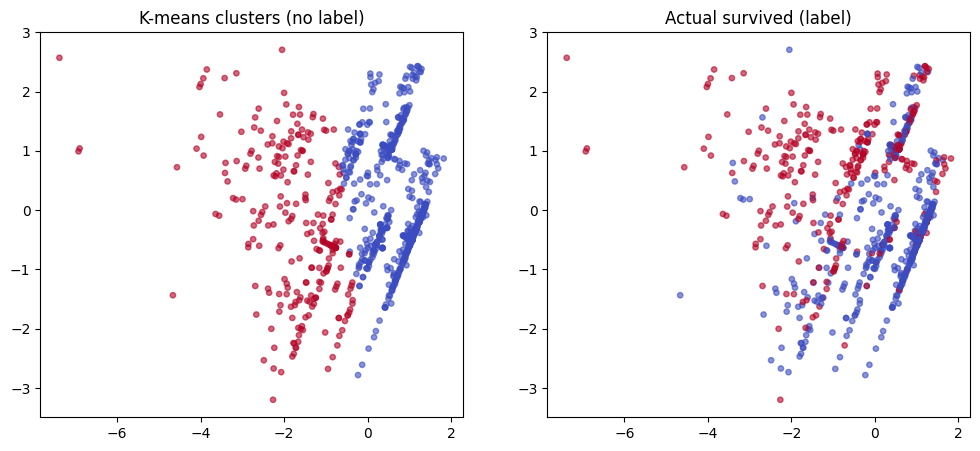

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유:
# fare(요금, 단위: 달러/수십~수백)와 age(나이, 단위: 세/수십)는 변수 간 scale(단위 크기) 차이가 큽니다.
# PCA와 K-means 모두 데이터 간의 '유클리드 거리(Euclidean Distance)' 및 '분산(Variance)'을 기준으로 작동하므로,
# 스케일링을 하지 않으면 스케일이 큰 fare 특성이 거리에 과도하게 큰 영향을 미쳐 결과를 왜곡하기 때문입니다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components=2, random_state=MY_SEED).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

해석
K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가?

답변: 좌측(K-means)과 우측(실제 생존) 그래프를 비교하면 전반적인 영역 분할 경향은 어느 정도 일치하지만, 경계선 부분과 오른쪽 세부 영역에서 실제 라벨과 완전히 겹치지 않고 오차가 크게 발생합니다. K-means는 중심점 기준 선형적인 경계로 데이터를 좌우 명확하게 구분(붉은색/파란색)한 반면, 실제 생존 데이터는 파란색 영역 안에도 붉은색 점이 섞여 있고 붉은색 영역 안에도 파란색 점이 섞여 있어 경계가 훨씬 복잡하고 서로 뒤얽혀 있습니다.

겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가?

답변: K-means는 실제 정답(Label)을 보지 않는 비지도학습 알고리즘으로, 오직 특성(Feature) 공간상 데이터 간의 '유클리드 거리(Euclidean Distance)'만을 기준으로 가장 가까운 군집 중심점(Centroid)에 데이터를 배치하기 때문입니다.

K-means는 거리를 기준으로 데이터를 기하학적으로 깔끔하게 잘라내기 때문에 직선 모양의 구분이 만들어집니다. 반면 '실제 생존 여부(Survived)'는 단순 거리 개념이 아니라 성별, 객실 등급, 나이, 동승자 수 등 여러 복합적 특성이 복잡한 비선형 규칙으로 작용하여 결정됩니다. 따라서 거리 기준의 K-means 클러스터링만으로는 실제 생존 여부 라벨의 복잡한 분포를 완벽하게 맞출 수 없습니다.

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → `_개념 질문, 코드 초안_`
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `_ai가 임의로 생각하고 결정한 부_`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
코드 보내고 ai한테 코드의 어떤 부분을 어떻게 써야 할지 물어봤습니다.
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `없음`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `산점도`
